# Week 2: Selective essentiality in TNBC (DepMap)

Compares gene dependency (Chronos scores) between the 25 TNBC cell lines
(from Week 1's `get_tnbc_model_ids`) and every other DepMap cell line with
CRISPR data, gene by gene. Runs **two** statistical tests side by side --
Welch's t-test and Mann-Whitney U -- per the discussion in `NOTES.md`, so
the choice of test can be checked empirically rather than assumed.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from scipy import stats

from data_utils import load_model_metadata, load_gene_effect, get_tnbc_model_ids

model = load_model_metadata()
effect = load_gene_effect()
print("Gene effect matrix:", effect.shape)


Gene effect matrix: (1208, 18531)


## Defining the two comparison groups

TNBC = the 25 cell lines from `get_tnbc_model_ids()` that have CRISPR data
(Week 1). The comparison group is meant to be "every other DepMap cell
line" per the project plan -- but 2 breast cell lines have no
`ModelSubtypeFeatures` value at all (unknown subtype, not confirmed
non-TNBC). Those get excluded from *both* groups, same "unknown isn't
automatically the other bucket" rule applied to DepMap's and TCGA's TNBC
mappings in Week 1 -- we don't actually know whether they're TNBC, so
including them in the "other" group risks quietly diluting it with
possible TNBC lines.


In [2]:
tnbc_ids = set(get_tnbc_model_ids(model)) & set(effect.index)

breast = model[model["OncotreeLineage"] == "Breast"]
unknown_subtype_ids = set(breast.index[breast["ModelSubtypeFeatures"].isna()]) & set(effect.index)

other_ids = set(effect.index) - tnbc_ids - unknown_subtype_ids

print(f"TNBC group: {len(tnbc_ids)} cell lines")
print(f"Excluded (unknown subtype): {len(unknown_subtype_ids)} cell lines")
print(f"Comparison ('other') group: {len(other_ids)} cell lines")

tnbc_df = effect.loc[sorted(tnbc_ids)]
other_df = effect.loc[sorted(other_ids)]


TNBC group: 25 cell lines
Excluded (unknown subtype): 2 cell lines
Comparison ('other') group: 1181 cell lines


## Running both tests, gene by gene

For each of the 18,531 genes: drop missing values within each group first
(DepMap's per-gene missingness from Week 1's EDA), require at least 3 valid
values in *both* groups to run a test at all (below that, neither test's
result means much), then run:

- **Welch's t-test** (`equal_var=False` -- doesn't assume the two groups
  have the same variance, which they likely don't given the 25-vs-1,181
  size difference).
- **Mann-Whitney U**, two-sided.

Effect size is the plain mean difference (TNBC mean minus other-group
mean) -- already in Chronos-score units, so a more negative value directly
means "more essential in TNBC than in the rest of DepMap."


In [3]:
records = []
for gene in effect.columns:
    a = tnbc_df[gene].dropna().to_numpy()
    b = other_df[gene].dropna().to_numpy()
    if len(a) < 3 or len(b) < 3:
        continue
    effect_size = a.mean() - b.mean()
    _, t_p = stats.ttest_ind(a, b, equal_var=False)
    _, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    records.append((gene, effect_size, t_p, u_p, len(a), len(b)))

results = pd.DataFrame(records, columns=["gene", "effect_size", "t_p", "u_p", "n_tnbc", "n_other"])
print(f"Genes tested: {len(results)} of {effect.shape[1]} (rest had <3 valid values in one group)")


Genes tested: 17931 of 18531 (rest had <3 valid values in one group)


## Multiple-testing correction

~18,500 simultaneous tests need correction, and Bonferroni would be far too
conservative for a project whose actual goal is a *shortlist for follow-up*,
not one confirmatory claim -- so Benjamini-Hochberg FDR (q-values) is used
instead, applied separately to each test's p-values.


In [4]:
results["t_q"] = stats.false_discovery_control(results["t_p"], method="bh")
results["u_q"] = stats.false_discovery_control(results["u_p"], method="bh")

results = results.sort_values("t_q")
results.to_csv("../data/processed/depmap_tnbc_essentiality.csv", index=False)
print(f"Saved {len(results)} rows to data/processed/depmap_tnbc_essentiality.csv")
results.head()


Saved 17931 rows to data/processed/depmap_tnbc_essentiality.csv


,gene,effect_size,t_p,u_p,n_tnbc,n_other,t_q,u_q
13233,RTTN,0.320892,9.326896e-08,4.152423e-07,25,1181,0.001672,0.007446
16813,VCF1,0.130184,1.292815e-05,7.350126e-06,25,1181,0.043475,0.026359
2548,CDKN1A,-0.174677,9.905352e-06,6.073085e-04,25,1181,0.043475,0.151421
3943,DET1,0.194568,1.204142e-05,2.981269e-04,25,1181,0.043475,0.122862
3201,COL5A1,0.108644,1.558827e-05,6.501065e-06,25,1181,0.043475,0.026359


## Comparing the two tests

Before trusting either ranking, check whether they actually agree -- if
Welch's t-test and Mann-Whitney U disagree substantially, that's a sign the
per-gene distributions are non-normal enough that the choice of test
matters a lot, and the more robust one (Mann-Whitney) should be trusted.


In [5]:
corr = stats.spearmanr(results["t_p"], results["u_p"])
print(f"Spearman correlation between the two tests' p-values: rho={corr.statistic:.4f} (p={corr.pvalue:.2e})")

QVAL_THRESHOLD = 0.10

sig_t = set(results.loc[(results["t_q"] < QVAL_THRESHOLD) & (results["effect_size"] < 0), "gene"])
sig_u = set(results.loc[(results["u_q"] < QVAL_THRESHOLD) & (results["effect_size"] < 0), "gene"])

print(f"\nSignificant + TNBC-selective (q < {QVAL_THRESHOLD}, effect_size < 0):")
print(f"  t-test:        {len(sig_t)} genes")
print(f"  Mann-Whitney:  {len(sig_u)} genes")
print(f"  Overlap:       {len(sig_t & sig_u)} genes ({len(sig_t & sig_u) / len(sig_t | sig_u):.1%} of the union)")


Spearman correlation between the two tests' p-values: rho=0.8727 (p=0.00e+00)

Significant + TNBC-selective (q < 0.1, effect_size < 0):
  t-test:        8 genes
  Mann-Whitney:  13 genes
  Overlap:       6 genes (40.0% of the union)


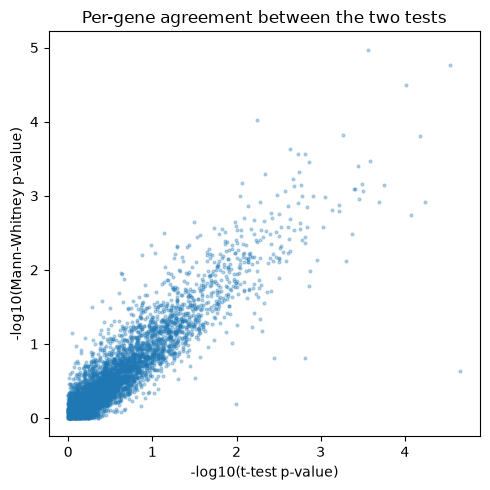

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
sample = results.sample(min(5000, len(results)), random_state=0)
ax.scatter(-np.log10(sample["t_p"]), -np.log10(sample["u_p"]), s=4, alpha=0.3)
lims = [0, max(-np.log10(results["t_p"]).max(), -np.log10(results["u_p"]).max())]
ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("-log10(t-test p-value)")
ax.set_ylabel("-log10(Mann-Whitney p-value)")
ax.set_title("Per-gene agreement between the two tests")
plt.tight_layout()
plt.show()


## Shortlist

Sorted by Mann-Whitney's q-value (the more robust test given the group-size
imbalance -- see `NOTES.md`'s test-choice discussion), restricted to genes
where TNBC is *more* essential (`effect_size < 0`). Both tests' q-values are
kept side by side so the choice of test is visible, not hidden.


In [7]:
shortlist = (
    results[results["effect_size"] < 0]
    .sort_values("u_q")
    .head(40)
    .reset_index(drop=True)
)
shortlist.to_csv("../data/processed/depmap_tnbc_shortlist.csv", index=False)
print(f"Shortlist: {len(shortlist)} genes -> data/processed/depmap_tnbc_shortlist.csv")
shortlist


Shortlist: 40 genes -> data/processed/depmap_tnbc_shortlist.csv


,gene,effect_size,t_p,u_p,n_tnbc,n_other,t_q,u_q
0,SMLR1,-0.099091,0.000112,0.000010,25,1181,0.077335,0.027395
1,BROX,-0.097161,0.000272,0.000011,25,1181,0.120132,0.027395
2,OR4K2,-0.087143,0.000029,0.000017,24,1065,0.052531,0.038335
3,GPAT3,-0.072505,0.000098,0.000031,25,1181,0.076191,0.056471
4,TMEM234,-0.090273,0.000196,0.000036,25,1181,0.102337,0.058863
5,POFUT1,-0.101217,0.000074,0.000047,25,1181,0.076191,0.070387
6,MTFR1L,-0.108383,0.000442,0.000052,25,1181,0.139586,0.072295
7,LIX1L,-0.097425,0.000281,0.000071,25,1181,0.120132,0.084970
8,CCDC82,-0.079358,0.000107,0.000087,25,1181,0.076755,0.088842
9,FMC1,-0.072236,0.000416,0.000104,25,1181,0.139586,0.088842


## Next: biological plausibility check

Per this project's guardrails, candidate rankings need to be checked
against known TNBC biology before being presented as findings -- not
assumed to be correct just because they're statistically significant.
That check (looking up whether the top candidates match published TNBC
dependencies) is the next step, done separately rather than guessed from
memory here.
